# Exploratory Data Analysis and Data Quality

 The dataset was loaded and inspected. The dataset contains 253,680 rows and 22 columns, with `Diabetes_binary` as the target variable.

The goal of Day 2 is to perform exploratory data analysis and data quality checks before building machine learning models.

In this notebook, we will analyze:
- Missing values
- Duplicate rows
- Target class imbalance
- Feature distributions
- Diabetes rate by important features
- Correlation with the target variable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
import os

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../reports", exist_ok=True)
os.makedirs("../reports/figures", exist_ok=True)

In [4]:
df = pd.read_csv("../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
day1_summary = {
    "dataset_shape": df.shape,
    "total_rows": df.shape[0],
    "total_columns": df.shape[1],
    "target_column": "Diabetes_binary",
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "target_distribution": df["Diabetes_binary"].value_counts().to_dict()
}

day1_summary

{'dataset_shape': (253680, 22),
 'total_rows': 253680,
 'total_columns': 22,
 'target_column': 'Diabetes_binary',
 'missing_values_total': 0,
 'duplicate_rows': 24206,
 'target_distribution': {0.0: 218334, 1.0: 35346}}

The dataset contains 253,680 rows and 22 columns. The target variable is `Diabetes_binary`.

There are no missing values in the dataset. However, there are 24,206 duplicate rows, which need further analysis before deciding whether to remove them.

The target distribution shows class imbalance, with many more non-diabetic records than diabetic records.

## 1. Missing Value Analysis

Missing values can affect model training and may require imputation or removal.  
In this step, we check whether any columns contain missing values.

In [6]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percentage
})

missing_summary

,missing_count,missing_percentage
Diabetes_binary,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0


In [7]:
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

Total missing values: 0


The dataset does not contain any missing values. Therefore, no missing value imputation is required. This simplifies the preprocessing stage because all features are already complete.

## 2. Duplicate Row Analysis

Duplicate rows are checked to understand whether repeated records exist in the dataset.  
Since this dataset is based on survey responses, duplicate rows may represent different individuals with identical responses, so they should not be removed blindly.

In [8]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 2))

Duplicate rows: 24206
Duplicate percentage: 9.54


In [9]:
df_duplicates = df[df.duplicated()]

df_duplicates.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0


In [10]:
df_no_duplicates = df.drop_duplicates()

print("Original shape:", df.shape)
print("Shape after removing duplicates:", df_no_duplicates.shape)

Original shape: (253680, 22)
Shape after removing duplicates: (229474, 22)


The dataset contains 24,206 duplicate rows, which represents approximately 9.54% of the dataset.

However, because this is a survey-based health dataset, exact duplicate rows may not necessarily be data errors. Multiple individuals can have the same values across all health indicators. Therefore, the original dataset will be preserved, and a duplicate-removed version will also be saved for comparison during modeling.

## 3. Target Class Distribution

The target variable is `Diabetes_binary`, where:

- `0` represents non-diabetic individuals
- `1` represents diabetic individuals

In this step, we analyze whether the target classes are balanced or imbalanced.

In [11]:
target_counts = df["Diabetes_binary"].value_counts()
target_percentages = df["Diabetes_binary"].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
})

target_distribution

,count,percentage
Diabetes_binary,,
0.0,218334,86.07
1.0,35346,13.93


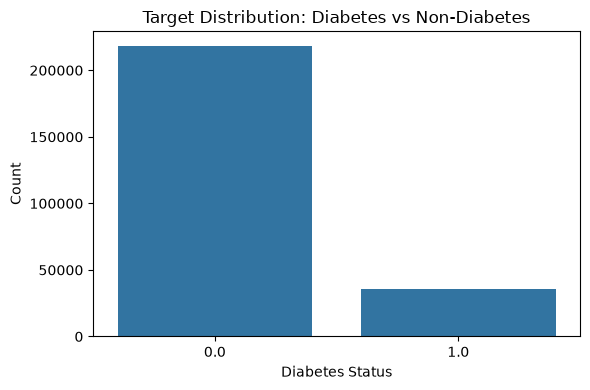

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Diabetes_binary")
plt.title("Target Distribution: Diabetes vs Non-Diabetes")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=300)
plt.show()

## 4. Feature Grouping

Before visualizing the data, the features are grouped based on their meaning and value types.

The dataset contains:
- Binary features: columns with two possible values, usually 0 or 1
- Ordinal features: ordered categorical values such as age group, income level, education level, and general health
- Continuous/count features: numerical features such as BMI and number of unhealthy days

In [14]:
target_col = "Diabetes_binary"

binary_cols = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex"
]

ordinal_cols = [
    "GenHlth",
    "Age",
    "Education",
    "Income"
]

continuous_cols = [
    "BMI",
    "MentHlth",
    "PhysHlth"
]

print("Target column:", target_col)
print("Number of binary columns:", len(binary_cols))
print("Number of ordinal columns:", len(ordinal_cols))
print("Number of continuous/count columns:", len(continuous_cols))

Target column: Diabetes_binary
Number of binary columns: 14
Number of ordinal columns: 4
Number of continuous/count columns: 3


In [15]:
all_grouped_cols = binary_cols + ordinal_cols + continuous_cols + [target_col]

missing_from_groups = set(df.columns) - set(all_grouped_cols)
extra_in_groups = set(all_grouped_cols) - set(df.columns)

print("Columns missing from feature groups:", missing_from_groups)
print("Extra columns not found in dataset:", extra_in_groups)

Columns missing from feature groups: set()
Extra columns not found in dataset: set()


In [16]:
for col in binary_cols + ordinal_cols:
    print(f"{col}: {sorted(df[col].unique())}")

HighBP: [np.float64(0.0), np.float64(1.0)]
HighChol: [np.float64(0.0), np.float64(1.0)]
CholCheck: [np.float64(0.0), np.float64(1.0)]
Smoker: [np.float64(0.0), np.float64(1.0)]
Stroke: [np.float64(0.0), np.float64(1.0)]
HeartDiseaseorAttack: [np.float64(0.0), np.float64(1.0)]
PhysActivity: [np.float64(0.0), np.float64(1.0)]
Fruits: [np.float64(0.0), np.float64(1.0)]
Veggies: [np.float64(0.0), np.float64(1.0)]
HvyAlcoholConsump: [np.float64(0.0), np.float64(1.0)]
AnyHealthcare: [np.float64(0.0), np.float64(1.0)]
NoDocbcCost: [np.float64(0.0), np.float64(1.0)]
DiffWalk: [np.float64(0.0), np.float64(1.0)]
Sex: [np.float64(0.0), np.float64(1.0)]
GenHlth: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
Age: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0)]
Education: [np.float64(1

The features were grouped into binary, ordinal, and continuous/count variables based on their meaning.

Most health behavior and medical history variables are binary. Age, general health, education, and income are ordinal because their values represent ordered categories. BMI, mental health days, and physical health days are treated as continuous/count variables.

This grouping will help organize the EDA visualizations and will also be useful later when building preprocessing and modeling pipelines.

## 5. Continuous and Count Feature Analysis

The continuous/count features in this dataset are:

- `BMI`: Body Mass Index
- `MentHlth`: Number of days mental health was not good in the past 30 days
- `PhysHlth`: Number of days physical health was not good in the past 30 days

These features are analyzed to understand their distributions and how they differ between diabetic and non-diabetic individuals.

In [17]:
df[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
MentHlth,253680.0,3.184772,7.412847,0.0,0.0,0.0,2.0,30.0
PhysHlth,253680.0,4.242081,8.717951,0.0,0.0,0.0,3.0,30.0


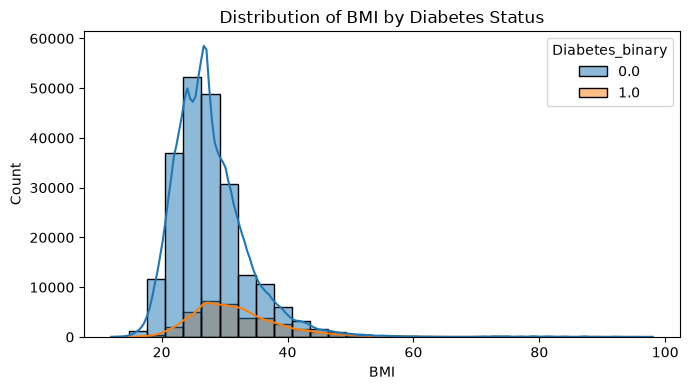

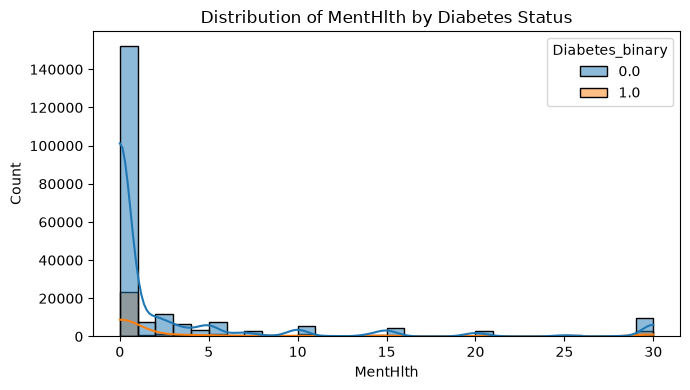

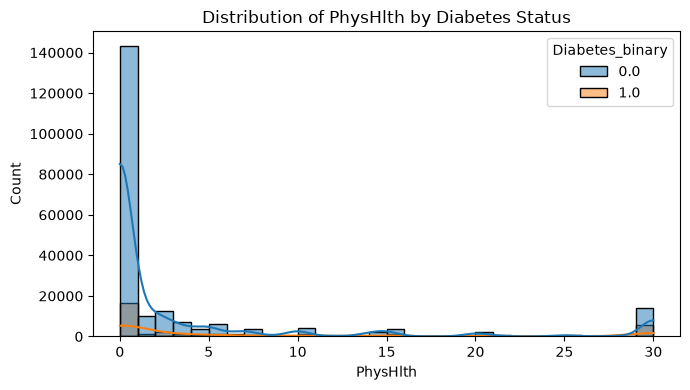

In [19]:
for col in continuous_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue="Diabetes_binary", bins=30, kde=True)
    plt.title(f"Distribution of {col} by Diabetes Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{col.lower()}_distribution_by_diabetes.png", dpi=300)
    plt.show()

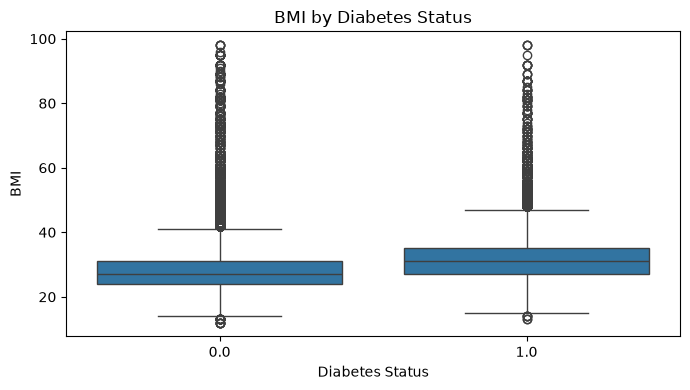

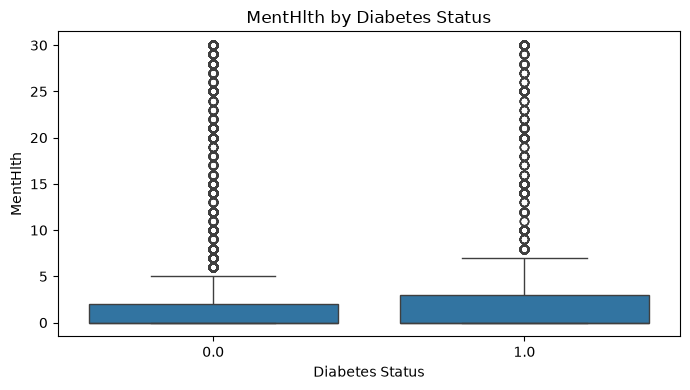

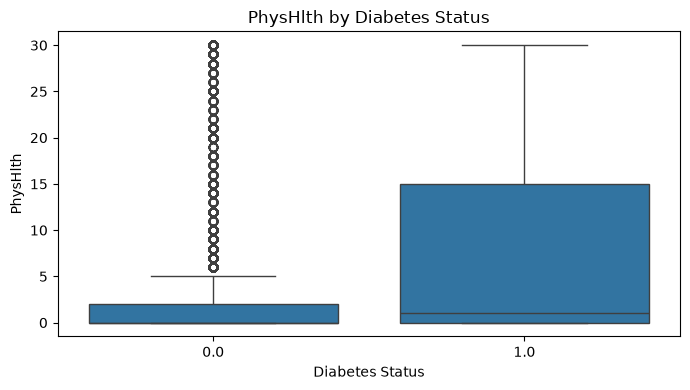

In [20]:
for col in continuous_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="Diabetes_binary", y=col)
    plt.title(f"{col} by Diabetes Status")
    plt.xlabel("Diabetes Status")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

BMI, mental health days, and physical health days show skewed distributions.

BMI is expected to be an important feature because higher BMI is commonly associated with higher diabetes risk. `MentHlth` and `PhysHlth` are count-based features ranging from 0 to 30 days, and many individuals report 0 unhealthy days, creating right-skewed distributions.

Outliers are not removed at this stage because high BMI or high unhealthy-day values may represent real health conditions. These values will be handled carefully during model training and evaluation.

## 6. Ordinal Feature Analysis

The ordinal features in this dataset are:

- `GenHlth`: General health rating
- `Age`: Age category
- `Education`: Education level
- `Income`: Income level

These variables contain ordered categories, so they are analyzed to understand how diabetes risk changes across different levels.

In [21]:
for col in ordinal_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts().sort_index())


Value counts for GenHlth:
GenHlth
1.0    45299
2.0    89084
3.0    75646
4.0    31570
5.0    12081
Name: count, dtype: int64

Value counts for Age:
Age
1.0      5700
2.0      7598
3.0     11123
4.0     13823
5.0     16157
6.0     19819
7.0     26314
8.0     30832
9.0     33244
10.0    32194
11.0    23533
12.0    15980
13.0    17363
Name: count, dtype: int64

Value counts for Education:
Education
1.0       174
2.0      4043
3.0      9478
4.0     62750
5.0     69910
6.0    107325
Name: count, dtype: int64

Value counts for Income:
Income
1.0     9811
2.0    11783
3.0    15994
4.0    20135
5.0    25883
6.0    36470
7.0    43219
8.0    90385
Name: count, dtype: int64


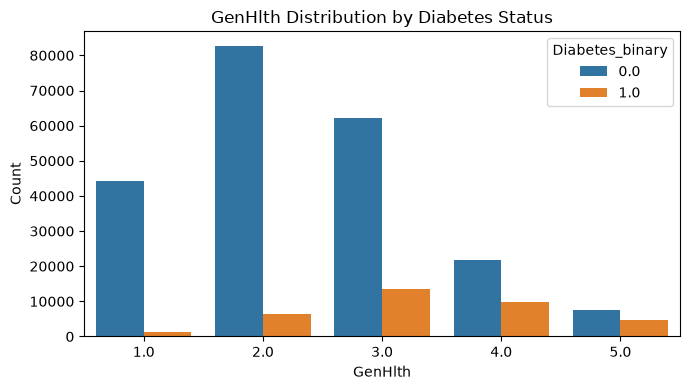

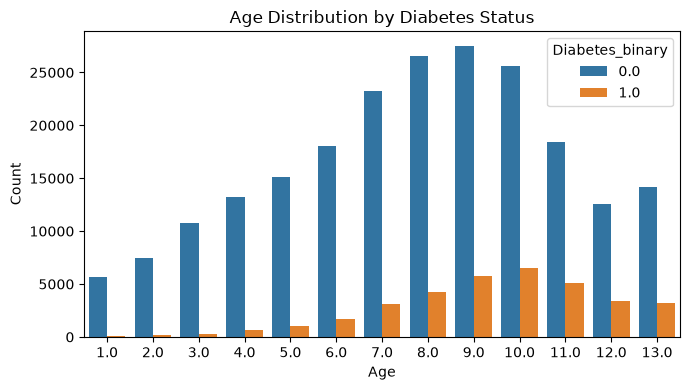

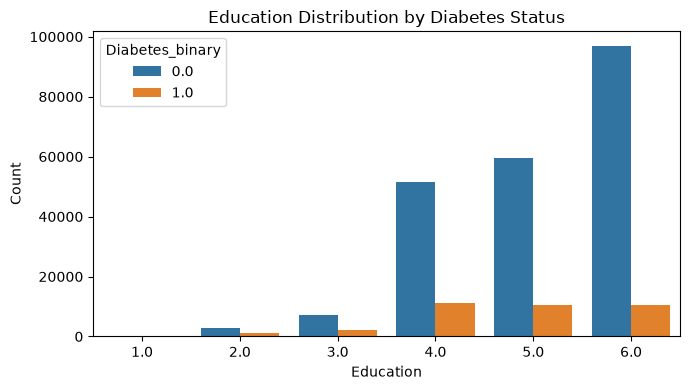

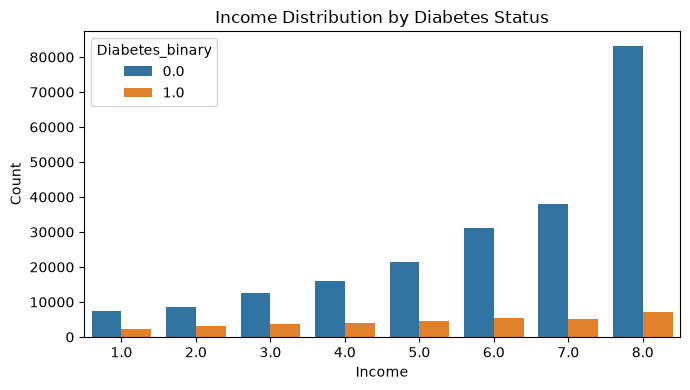

In [22]:
for col in ordinal_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="Diabetes_binary")
    plt.title(f"{col} Distribution by Diabetes Status")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{col.lower()}_distribution_by_diabetes.png", dpi=300)
    plt.show()

The ordinal features show how diabetes status varies across ordered categories.

`GenHlth` and `Age` are expected to be highly useful because diabetes risk often increases with poorer general health and older age groups. `Education` and `Income` may also provide useful socioeconomic information related to health outcomes.

## 7. Diabetes Rate by Ordinal Features

Instead of only checking raw counts, we calculate the diabetes rate within each category.

This helps us understand how diabetes prevalence changes across ordered groups such as general health, age, education, and income.

In [23]:
for col in ordinal_cols:
    diabetes_rate = df.groupby(col)["Diabetes_binary"].mean() * 100
    
    print(f"\nDiabetes Rate by {col}:")
    print(diabetes_rate.round(2))


Diabetes Rate by GenHlth:
GenHlth
1.0     2.52
2.0     7.16
3.0    17.79
4.0    31.01
5.0    37.89
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Age:
Age
1.0      1.37
2.0      1.84
3.0      2.82
4.0      4.53
5.0      6.50
6.0      8.79
7.0     11.74
8.0     13.83
9.0     17.25
10.0    20.37
11.0    21.85
12.0    21.30
13.0    18.48
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Education:
Education
1.0    27.01
2.0    29.26
3.0    24.22
4.0    17.64
5.0    14.81
6.0     9.69
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Income:
Income
1.0    24.29
2.0    26.19
3.0    22.31
4.0    20.13
5.0    17.40
6.0    14.51
7.0    12.18
8.0     7.96
Name: Diabetes_binary, dtype: float64


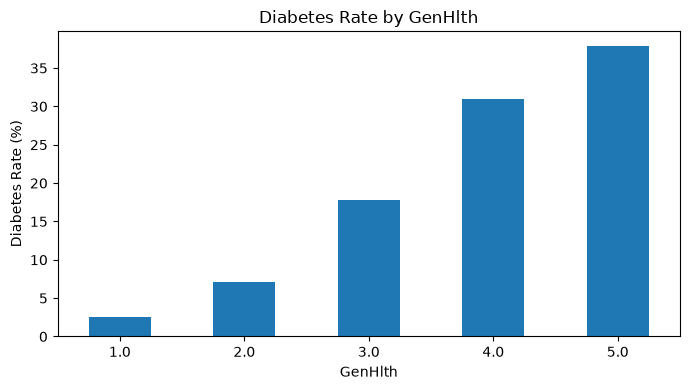

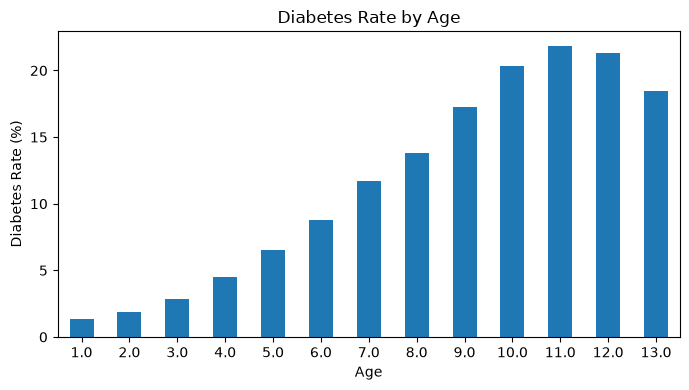

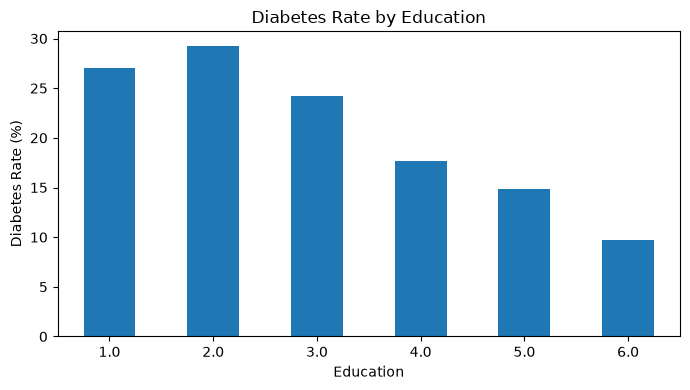

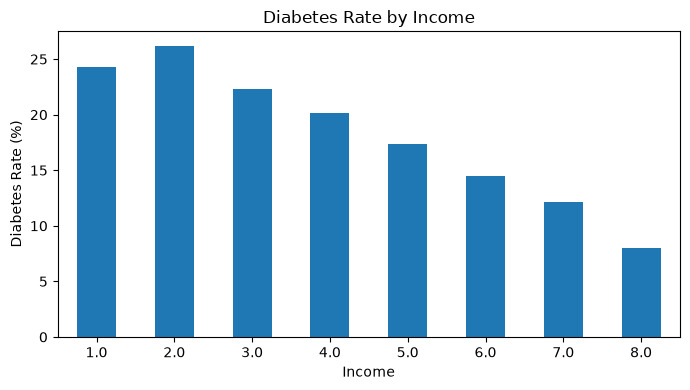

In [24]:
for col in ordinal_cols:
    diabetes_rate = df.groupby(col)["Diabetes_binary"].mean() * 100
    
    plt.figure(figsize=(7, 4))
    diabetes_rate.plot(kind="bar")
    plt.title(f"Diabetes Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Diabetes Rate (%)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"../reports/figures/diabetes_rate_by_{col.lower()}.png", dpi=300)
    plt.show()

The diabetes rate analysis provides more useful insight than raw count plots.

`GenHlth` shows a strong relationship with diabetes risk. As general health ratings become worse, the diabetes rate increases.

`Age` also shows an increasing trend, where older age groups generally have higher diabetes prevalence.

`Education` and `Income` may show socioeconomic patterns related to diabetes risk, although these relationships may be weaker than general health, age, BMI, high blood pressure, and high cholesterol.

## 8. Diabetes Rate by Binary Features

The dataset contains several binary health indicators such as high blood pressure, high cholesterol, smoking status, stroke history, physical activity, and difficulty walking.

For each binary feature, we calculate the diabetes rate for category `0` and category `1`. This helps identify which health indicators are strongly associated with diabetes risk.

In [25]:
for col in binary_cols:
    diabetes_rate = df.groupby(col)["Diabetes_binary"].mean() * 100
    
    print(f"\nDiabetes Rate by {col}:")
    print(diabetes_rate.round(2))


Diabetes Rate by HighBP:
HighBP
0.0     6.04
1.0    24.45
Name: Diabetes_binary, dtype: float64

Diabetes Rate by HighChol:
HighChol
0.0     7.98
1.0    22.01
Name: Diabetes_binary, dtype: float64

Diabetes Rate by CholCheck:
CholCheck
0.0     2.54
1.0    14.37
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Smoker:
Smoker
0.0    12.06
1.0    16.29
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Stroke:
Stroke
0.0    13.18
1.0    31.75
Name: Diabetes_binary, dtype: float64

Diabetes Rate by HeartDiseaseorAttack:
HeartDiseaseorAttack
0.0    11.95
1.0    32.97
Name: Diabetes_binary, dtype: float64

Diabetes Rate by PhysActivity:
PhysActivity
0.0    21.14
1.0    11.61
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Fruits:
Fruits
0.0    15.79
1.0    12.86
Name: Diabetes_binary, dtype: float64

Diabetes Rate by Veggies:
Veggies
0.0    18.00
1.0    12.99
Name: Diabetes_binary, dtype: float64

Diabetes Rate by HvyAlcoholConsump:
HvyAlcoholConsump
0.0    14.42
1.0    

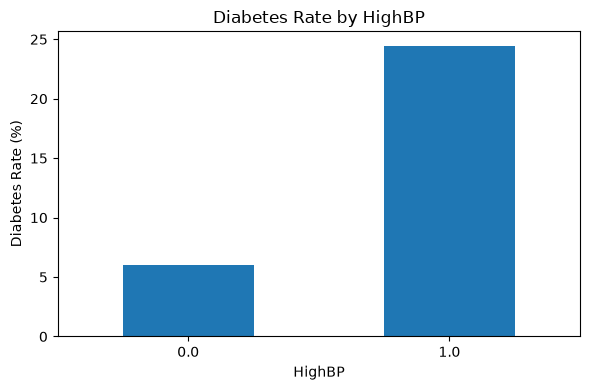

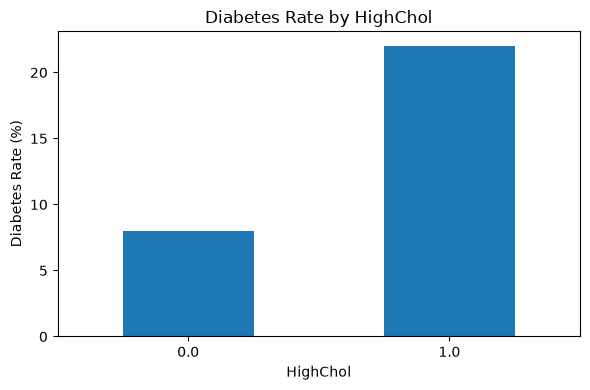

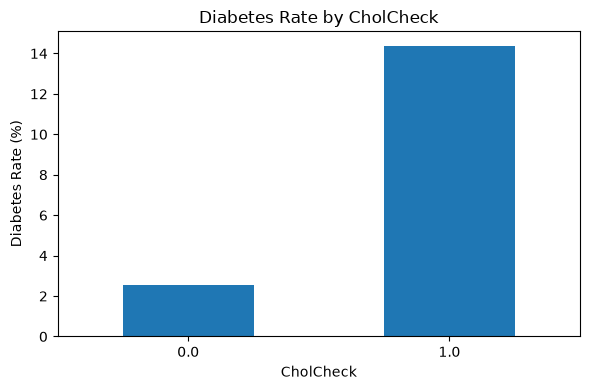

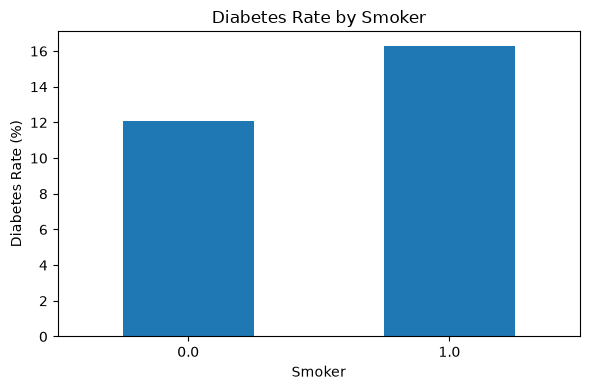

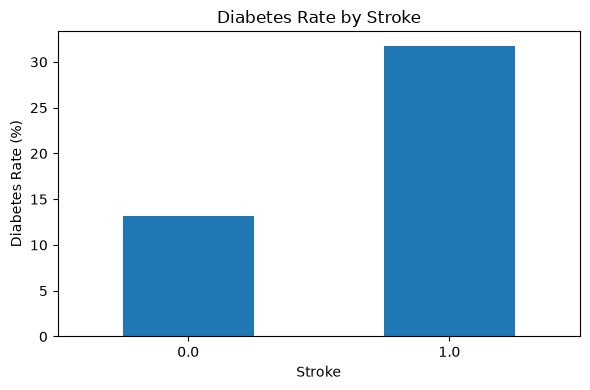

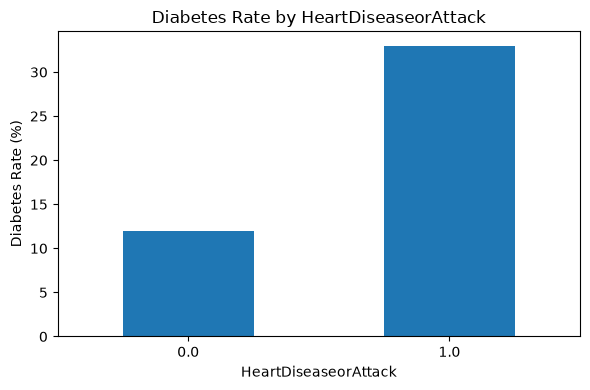

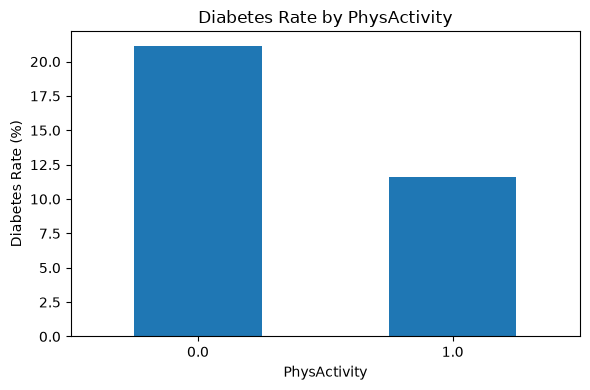

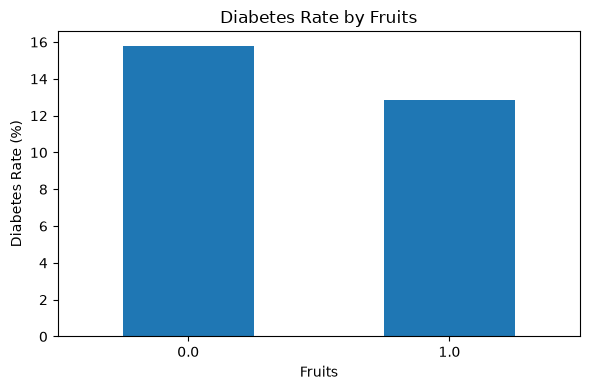

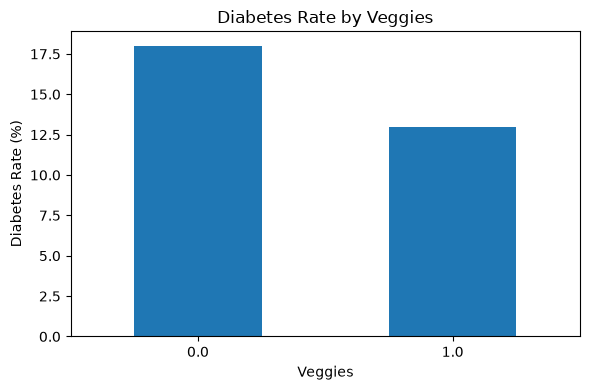

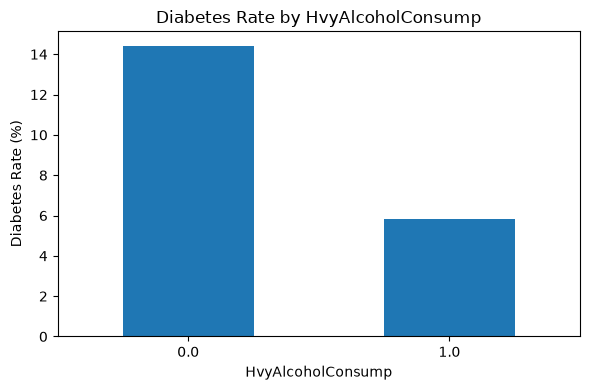

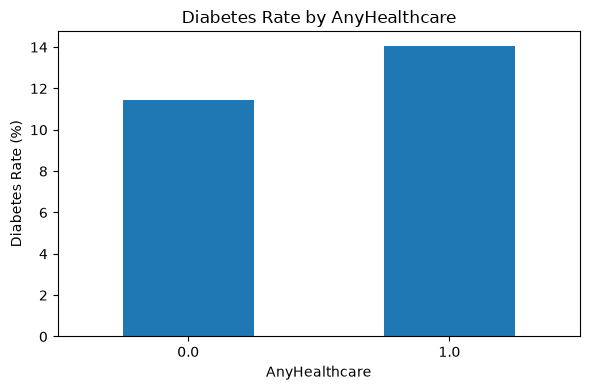

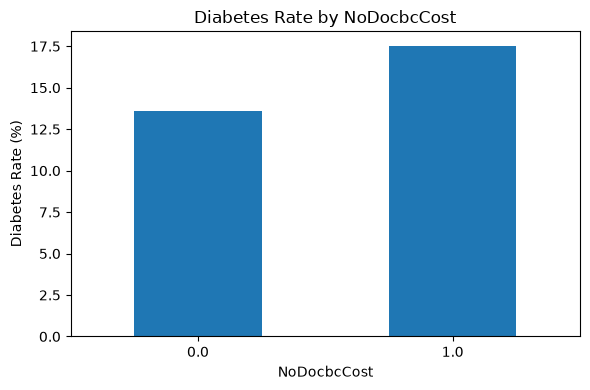

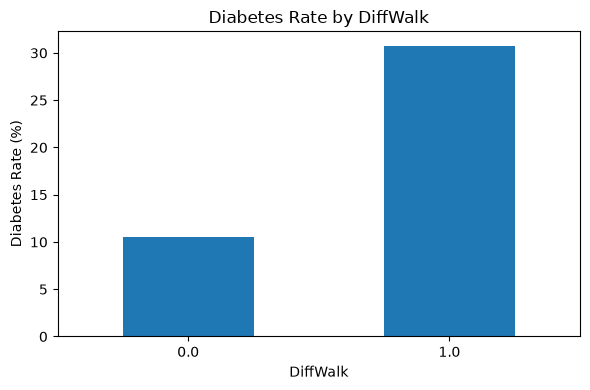

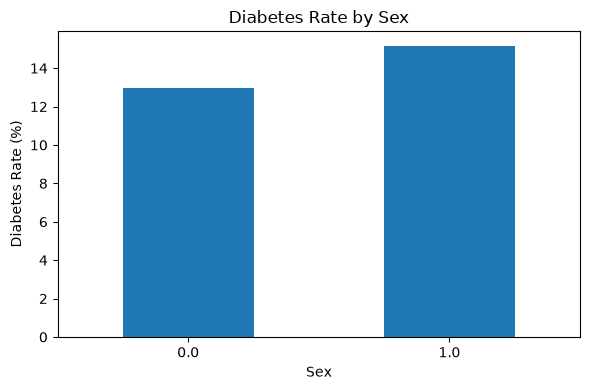

In [26]:
for col in binary_cols:
    diabetes_rate = df.groupby(col)["Diabetes_binary"].mean() * 100
    
    plt.figure(figsize=(6, 4))
    diabetes_rate.plot(kind="bar")
    plt.title(f"Diabetes Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Diabetes Rate (%)")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"../reports/figures/diabetes_rate_by_{col.lower()}.png", dpi=300)
    plt.show()

Binary feature analysis helps identify which health indicators are associated with higher diabetes prevalence.

Features such as `HighBP`, `HighChol`, `HeartDiseaseorAttack`, `Stroke`, and `DiffWalk` are expected to show higher diabetes rates when their value is `1`.

Lifestyle-related variables such as `PhysActivity`, `Fruits`, `Veggies`, and `HvyAlcoholConsump` may also provide useful information, but their relationships may be weaker or more indirect compared to medical history features.

The binary feature analysis shows that individuals with high blood pressure and high cholesterol have much higher diabetes rates compared to individuals without those conditions.

`HighBP` shows one of the strongest relationships with diabetes risk. Individuals with high blood pressure have a diabetes rate of approximately 24.45%, compared to only 6.04% among individuals without high blood pressure.

`HighChol` also shows a strong relationship, with individuals having high cholesterol showing a diabetes rate of approximately 22.01%, compared to 7.98% for individuals without high cholesterol.

Smoking shows a smaller difference compared to medical history features, suggesting that clinical indicators such as blood pressure and cholesterol may be more directly useful for diabetes prediction in this dataset.

## 9. Correlation with Target Variable

Correlation analysis helps identify which numerical features have the strongest linear relationship with the target variable `Diabetes_binary`.

Although correlation does not prove causation, it provides a useful starting point for understanding important features before model training.

In [27]:
corr_with_target = df.corr()["Diabetes_binary"].sort_values(ascending=False)

corr_with_target

Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64

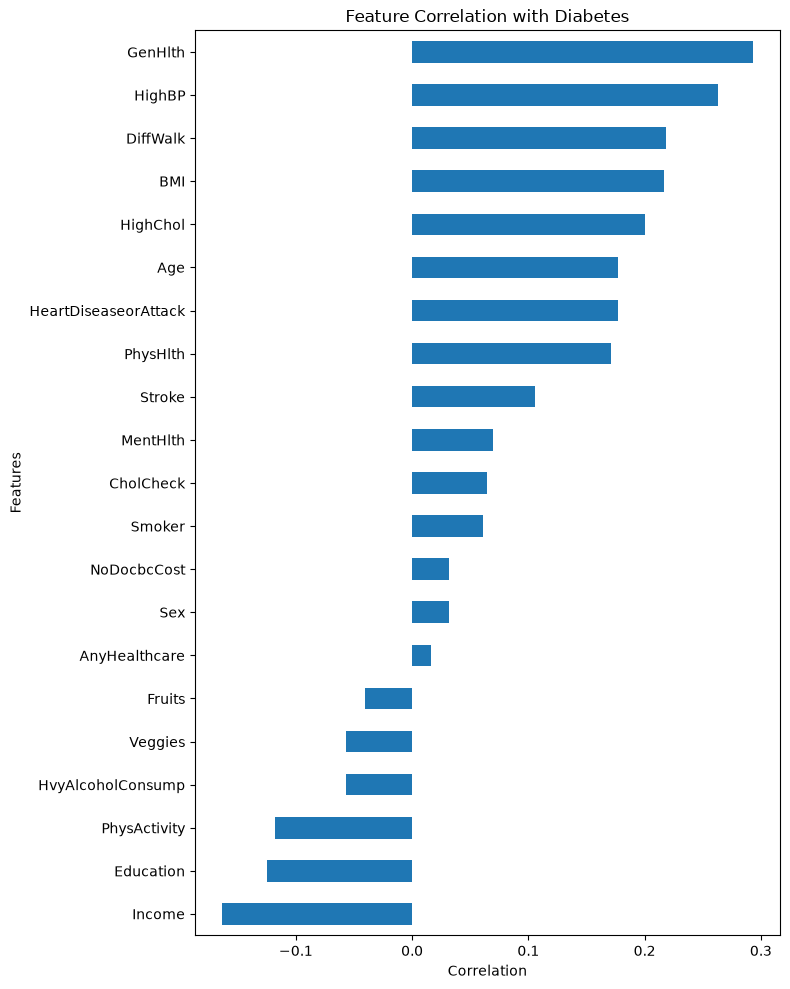

In [28]:
plt.figure(figsize=(8, 10))
corr_with_target.drop("Diabetes_binary").sort_values().plot(kind="barh")
plt.title("Feature Correlation with Diabetes")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_with_diabetes.png", dpi=300)
plt.show()

The correlation analysis shows which features have the strongest relationship with diabetes status.

Features such as `GenHlth`, `HighBP`, `BMI`, `HighChol`, `Age`, `DiffWalk`, and `HeartDiseaseorAttack` are expected to show stronger positive correlation with diabetes.

Features such as `Income`, `Education`, and `PhysActivity` may show negative correlation, meaning higher values or healthier behaviors may be associated with lower diabetes prevalence.

## 10. Correlation Heatmap

A correlation heatmap is used to visualize relationships between all numerical features in the dataset.

This helps identify:
- Features strongly related to `Diabetes_binary`
- Features that may be related to each other
- Possible multicollinearity patterns before model training

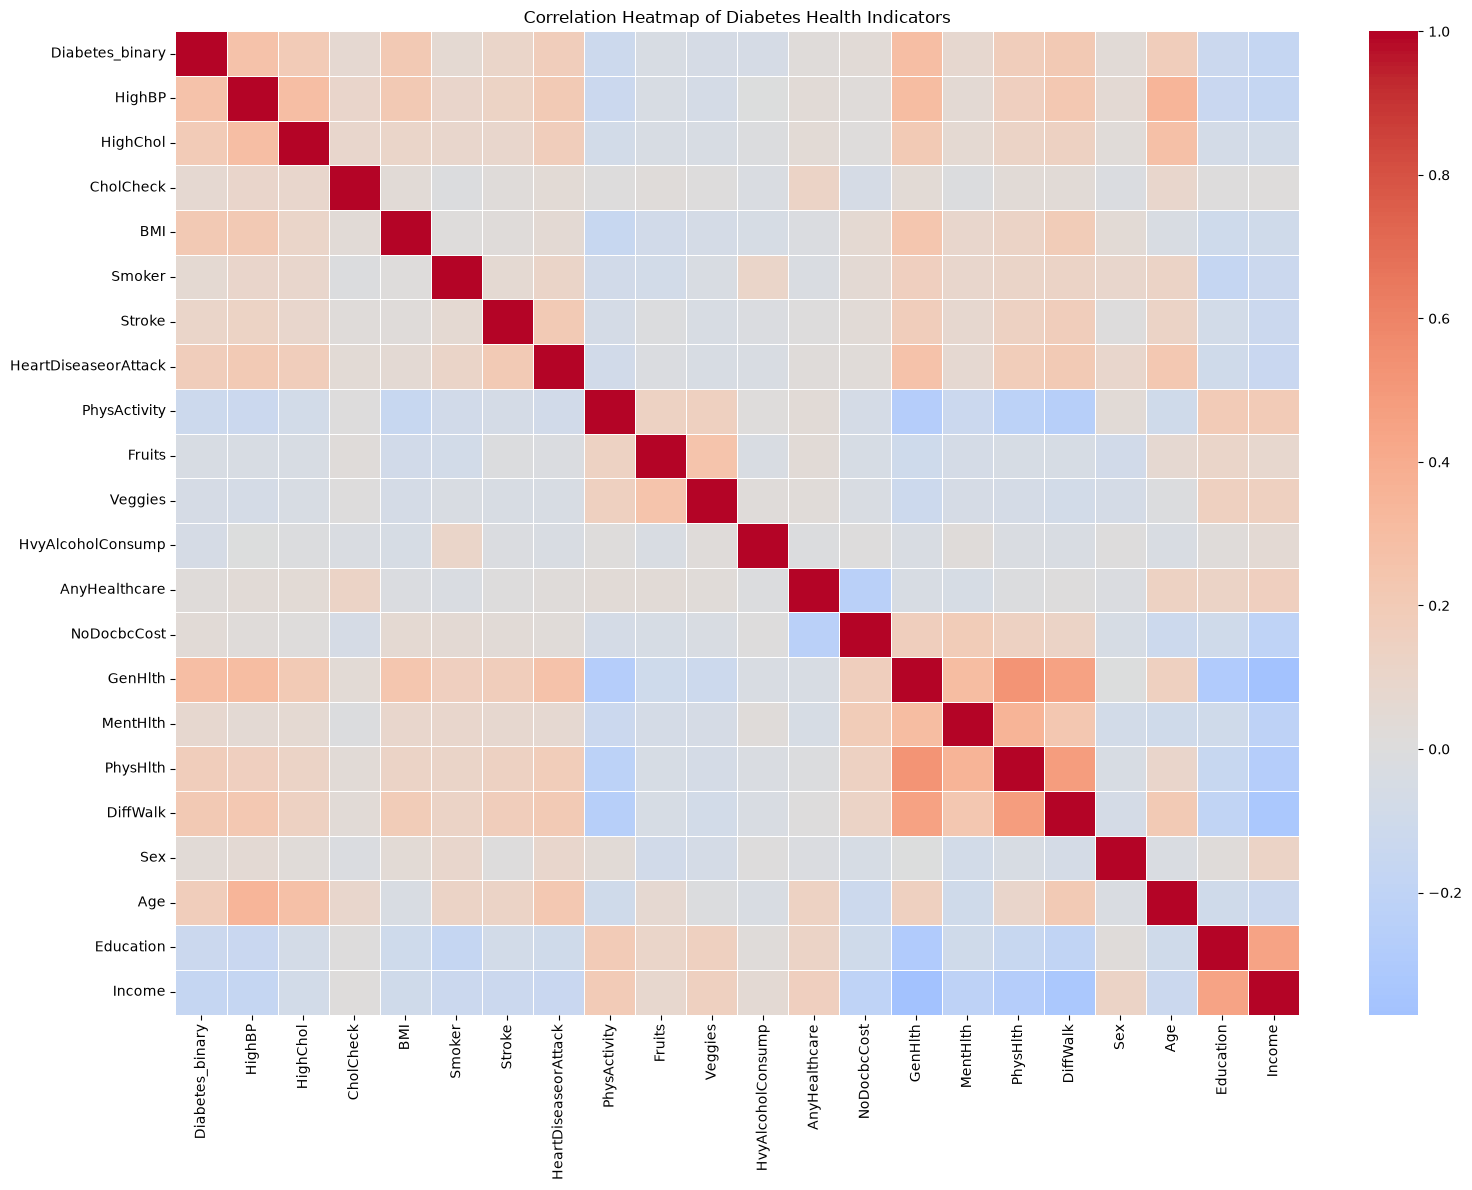

In [30]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=False
)

plt.title("Correlation Heatmap of Diabetes Health Indicators")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=300)
plt.show()

The correlation heatmap provides an overview of relationships between all features.

The target variable `Diabetes_binary` shows stronger positive relationships with features such as general health, high blood pressure, BMI, high cholesterol, age, difficulty walking, and heart disease or attack.

Some features may also be related to each other, such as physical health, difficulty walking, general health, and age. These relationships will be considered later during model training and interpretation.

In [34]:
df.to_csv("../data/processed/diabetes_original.csv", index=False)
df_no_duplicates.to_csv("../data/processed/diabetes_no_duplicates.csv", index=False)

print("Saved original dataset:", "../data/processed/diabetes_original.csv")
print("Saved duplicate-removed dataset:", "../data/processed/diabetes_no_duplicates.csv")


Saved original dataset: ../data/processed/diabetes_original.csv
Saved duplicate-removed dataset: ../data/processed/diabetes_no_duplicates.csv


In [35]:
eda_summary = {
    "dataset_shape": list(df.shape),
    "total_rows": int(df.shape[0]),
    "total_columns": int(df.shape[1]),
    "target_column": target_col,
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "duplicate_percentage": round(float(df.duplicated().sum() / len(df) * 100), 2),
    "target_distribution": {
        str(k): int(v) for k, v in df[target_col].value_counts().to_dict().items()
    },
    "target_percentage": {
        str(k): round(float(v), 2) 
        for k, v in (df[target_col].value_counts(normalize=True) * 100).to_dict().items()
    },
    "feature_groups": {
        "binary_columns": binary_cols,
        "ordinal_columns": ordinal_cols,
        "continuous_count_columns": continuous_cols
    },
    "top_positive_correlations_with_target": {
        k: round(float(v), 4) 
        for k, v in corr_with_target.drop(target_col).head(10).to_dict().items()
    },
    "top_negative_correlations_with_target": {
        k: round(float(v), 4) 
        for k, v in corr_with_target.drop(target_col).tail(10).to_dict().items()
    }
}

eda_summary

{'dataset_shape': [253680, 22],
 'total_rows': 253680,
 'total_columns': 22,
 'target_column': 'Diabetes_binary',
 'missing_values_total': 0,
 'duplicate_rows': 24206,
 'duplicate_percentage': 9.54,
 'target_distribution': {'0.0': 218334, '1.0': 35346},
 'target_percentage': {'0.0': 86.07, '1.0': 13.93},
 'feature_groups': {'binary_columns': ['HighBP',
   'HighChol',
   'CholCheck',
   'Smoker',
   'Stroke',
   'HeartDiseaseorAttack',
   'PhysActivity',
   'Fruits',
   'Veggies',
   'HvyAlcoholConsump',
   'AnyHealthcare',
   'NoDocbcCost',
   'DiffWalk',
   'Sex'],
  'ordinal_columns': ['GenHlth', 'Age', 'Education', 'Income'],
  'continuous_count_columns': ['BMI', 'MentHlth', 'PhysHlth']},
 'top_positive_correlations_with_target': {'GenHlth': 0.2936,
  'HighBP': 0.2631,
  'DiffWalk': 0.2183,
  'BMI': 0.2168,
  'HighChol': 0.2003,
  'Age': 0.1774,
  'HeartDiseaseorAttack': 0.1773,
  'PhysHlth': 0.1713,
  'Stroke': 0.1058,
  'MentHlth': 0.0693},
 'top_negative_correlations_with_target'

In [36]:
with open("../reports/eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=4)

print("EDA summary saved to ../reports/eda_summary.json")

EDA summary saved to ../reports/eda_summary.json


In [37]:
print("Processed data files:")
print(os.listdir("../data/processed"))

print("\nReports files:")
print(os.listdir("../reports"))

print("\nFigures files:")
print(os.listdir("../reports/figures")[:10])

Processed data files:
['diabetes_no_duplicates.csv', 'diabetes_original.csv', 'diabetes_Basic_validated.csv']

Reports files:
['day1_statistical_summary.csv', 'eda_summary.json', '.DS_Store', 'day1_target_distribution.csv', 'day1_target_correlations.csv', 'day1_feature_summary.csv', 'figures', 'day1_missing_values_report.csv', 'day1_summary.txt']

Figures files:
['menthlth_distribution_by_diabetes.png', 'correlation_with_diabetes.png', 'diabetes_rate_by_heartdiseaseorattack.png', 'diabetes_rate_by_stroke.png', 'diabetes_rate_by_hvyalcoholconsump.png', 'diabetes_rate_by_fruits.png', 'diabetes_rate_by_sex.png', 'education_distribution_by_diabetes.png', 'diabetes_rate_by_genhlth.png', 'diabetes_rate_by_veggies.png']


The original dataset and duplicate-removed dataset were saved for future modeling experiments.

The original dataset will be used as the main dataset initially because duplicate survey responses may represent different individuals with identical health profiles. The duplicate-removed dataset is also preserved so model performance can be compared later if needed.

An EDA summary file was saved in JSON format to document dataset quality, class distribution, feature groups, and important correlation findings.
